# Paper plots

Load the full-dataset autoencoder checkpoints from `ae_final_results.csv` plus the final v27 autoencoder, load their training histories, and generate publication figures.

In [27]:
from __future__ import annotations

import inspect
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch

# Work whether the notebook is launched from the repository root or Code/notebooks.
PROJECT_ROOT = next(
    candidate for candidate in [Path.cwd(), *Path.cwd().parents]
    if (candidate / "Code" / "results" / "tables" / "ae_final_results.csv").is_file()
)
CODE_ROOT = PROJECT_ROOT / "Code"
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from Code.src.models.autoencoder import ProteinSequenceAutoencoder

RESULTS_TABLE = CODE_ROOT / "results" / "tables" / "ae_final_results.csv"
FIGURES_DIR = CODE_ROOT / "notebooks" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Project root: {PROJECT_ROOT}")
print(f"Loading checkpoints on: {device}")

Project root: /Users/josh/GWU/protein-sequence-augmentation
Loading checkpoints on: cpu


## Load selected checkpoints and histories

In [28]:
final_results = pd.read_csv(RESULTS_TABLE)
assert len(final_results) == 4, f"Expected four selected models, found {len(final_results)}"
display(final_results)

RUN_FILES = {
    "Baseline GRU": {
        "checkpoint": "checkpoints/autoencoder/solubility/v5/model_ae_solubility.pt",
        "history": "Code/results/autoencoder/solubility/v5/solubility_ae_history.json",
    },
    "Compact GRU": {
        "checkpoint": "checkpoints/autoencoder/solubility/v12/model_ae_length_2_of_3_solubility_lr0p0003_num_layers2_hidden_dim512.pt",
        "history": "Code/results/autoencoder/solubility/v12/v12_model_ae_length_2_of_3_solubility_lr0p0003_num_layers2_hidden_dim512_history.json",
    },
    "High-capacity GRU": {
        "checkpoint": "checkpoints/autoencoder/solubility/v12/model_ae_length_2_of_3_solubility_lr0p0001_num_layers3_hidden_dim1024.pt",
        "history": "Code/results/autoencoder/solubility/v12/v12_model_ae_length_2_of_3_solubility_lr0p0001_num_layers3_hidden_dim1024_history.json",
    },
    "Final full-data GRU": {
        "checkpoint": "checkpoints/autoencoder/solubility/v23/model_ae_length_3_of_3_solubility.pt",
        "history": "Code/results/autoencoder/solubility/v23/v23_model_ae_length_3_of_3_solubility_history.json",
    },
}
V27_FILES = {
    "checkpoint": "checkpoints/autoencoder/solubility/v27/model_ae_length_3_of_3_solubility.pt",
    "history": "Code/results/autoencoder/solubility/v27/v27_model_ae_length_3_of_3_solubility_history.json",
}
assert set(final_results["model"]) == set(RUN_FILES), "Run mapping does not match ae_final_results.csv"
reconstruction_results = final_results.loc[final_results["version"] != "v12"].reset_index(drop=True)

,model,version,distinguishing_feature,training_data,learning_rate,hidden_dim,latent_dim,num_layers,teacher_forced_test_loss,teacher_forced_test_accuracy
0,Baseline GRU,v5,Initial full-dataset baseline; length curriculum,Full dataset,0.0010,512,512,2,1.131063,0.581860
1,Compact GRU,v12,Lower-cost 2-layer + 512-hidden model,Cumulative length bins 1-2 of 3,0.0003,512,256,2,0.687618,0.732385
2,High-capacity GRU,v12,3-layer + 1024-hidden model,Cumulative length bins 1-2 of 3,0.0001,1024,256,3,0.643609,0.756988
3,Final full-data GRU,v23,Final model trained with all three length bins,Full dataset (length bins 1-3 of 3),0.0003,512,256,2,1.042419,0.604436


In [29]:
def checkpoint_state_dict(checkpoint):
    if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        return checkpoint["model_state_dict"]
    if isinstance(checkpoint, dict):
        return checkpoint
    raise TypeError(f"Unsupported checkpoint type: {type(checkpoint).__name__}")


def load_selected_run(name, files):
    checkpoint_path = PROJECT_ROOT / files["checkpoint"]
    history_path = PROJECT_ROOT / files["history"]
    if not checkpoint_path.is_file() or not history_path.is_file():
        raise FileNotFoundError(f"Missing artifacts for {name}: {checkpoint_path}, {history_path}")

    with history_path.open() as handle:
        history = json.load(handle)

    # Training-only settings (for example learning_rate and patience) are not
    # model constructor arguments, so retain only architecture parameters.
    constructor_keys = set(inspect.signature(ProteinSequenceAutoencoder).parameters)
    model_parameters = {
        key: value for key, value in history["hyperparameters"].items()
        if key in constructor_keys
    }
    model = ProteinSequenceAutoencoder(**model_parameters).to(device)
    try:
        checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=True)
    except TypeError:  # Compatibility with older PyTorch versions.
        checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint_state_dict(checkpoint))
    model.eval()
    return model, history


models = {}
histories = {}
for model_name in reconstruction_results["model"]:
    models[model_name], histories[model_name] = load_selected_run(
        model_name, RUN_FILES[model_name]
    )
    print(f"Loaded {model_name}: {len(histories[model_name]['epochs'])} epochs")

models["Final AE"], histories["Final AE"] = load_selected_run("Final AE", V27_FILES)
print(f"Loaded Final AE (v27): {len(histories['Final AE']['epochs'])} epochs")

Loaded Baseline GRU: 100 epochs
Loaded Final full-data GRU: 200 epochs
Loaded Final AE (v27): 200 epochs


/Users/josh/GWU/protein-sequence-augmentation/Code/src/models/autoencoder.py:86: UserWarning: latent_dim should ideally be smaller than hidden_dim for effective compression
  warnings.warn("latent_dim should ideally be smaller than hidden_dim for effective compression", UserWarning)


## Teacher-forced reconstruction accuracy

Validation accuracy is measured with teacher forcing during training. Diamond markers show the final teacher-forced test accuracies reported in the results table.

Saved /Users/josh/GWU/protein-sequence-augmentation/Code/notebooks/figures/teacher_forced_reconstruction_accuracy.pdf


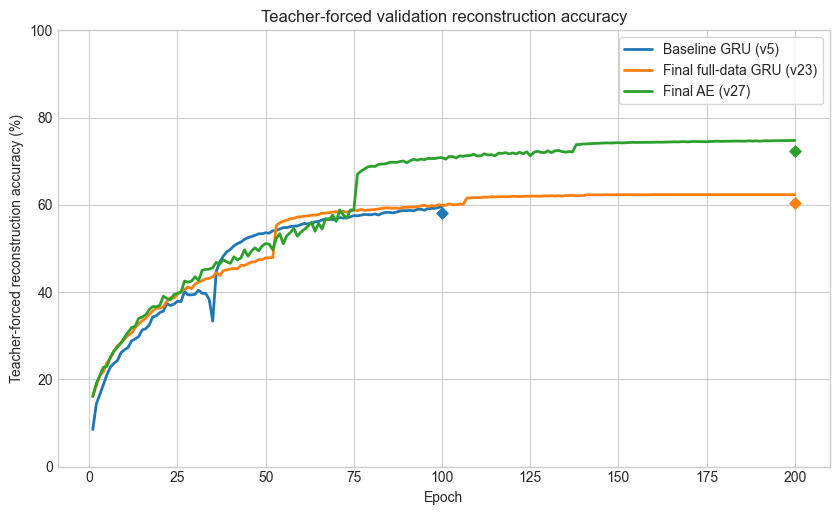

In [30]:
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(8.5, 5.25))
colors = plt.get_cmap("tab10").colors
reconstruction_labels = {
    "Final full-data GRU": "Full-data AE, 256-d latent bottleneck (v23)",
}

for index, row in reconstruction_results.iterrows():
    model_name = row["model"]
    epoch_history = pd.DataFrame(histories[model_name]["epochs"])
    color = colors[index]
    ax.plot(
        epoch_history["epoch"],
        100 * epoch_history["val_accuracy"],
        label=reconstruction_labels.get(model_name, f"{model_name} ({row['version']})"),
        color=color,
        linewidth=2,
    )
    ax.scatter(
        epoch_history["epoch"].iloc[-1],
        100 * row["teacher_forced_test_accuracy"],
        color=color, marker="D", s=32, zorder=3,
    )

v27_history = pd.DataFrame(histories["Final AE"]["epochs"])
v27_color = colors[len(reconstruction_results)]
ax.plot(
    v27_history["epoch"],
    100 * v27_history["val_accuracy"],
    label="Final AE, 512-d latent bottleneck (v27)",
    color=v27_color,
    linewidth=2,
)
ax.scatter(
    v27_history["epoch"].iloc[-1],
    100 * histories["Final AE"]["test"]["teacher_forced"]["accuracy"],
    color=v27_color, marker="D", s=32, zorder=3,
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Teacher-forced reconstruction accuracy (%)")
ax.set_title("Teacher-forced validation reconstruction accuracy")
ax.set_ylim(0, 100)
ax.legend(frameon=True)
fig.tight_layout()

figure_path = FIGURES_DIR / "teacher_forced_reconstruction_accuracy.pdf"
fig.savefig(figure_path, format="pdf", bbox_inches="tight")
print(f"Saved {figure_path}")
plt.show()

## v27 benchmark reconstruction accuracy by length third

The thirds are defined from the training-set sequence-length distribution and applied unchanged to the test set. Accuracy is micro-averaged over all non-padding target tokens in each bin, including EOS, matching the project's reported teacher-forced test accuracy.

In [31]:
import numpy as np

from Code.src.utils.dataloader import (
    PAD_IDX,
    compute_train_length_boundaries,
    create_dataloader,
)

DATA_ROOT = PROJECT_ROOT / "data" / "processed" / "peer"
loader_options = dict(
    data_dir=DATA_ROOT,
    cache_dir=DATA_ROOT / "cache",
    task="solubility",
    mode="autoencoder",
    batch_size=32,
    shuffle=False,
    num_workers=0,
)
train_loader = create_dataloader(split="train", **loader_options)
third_boundaries = compute_train_length_boundaries(train_loader.dataset, num_bins=3)
print("Training-derived third boundaries:", third_boundaries)

third_labels = ["Shortest third", "Middle third", "Longest third"]
v27_bin_rows = []
v27_model = models["Final AE"]

for bin_number, bin_label in enumerate(third_labels, start=1):
    test_bin_loader = create_dataloader(
        split="test",
        loader_type="length_bin",
        length_options="thirds",
        length_bin=bin_number,
        length_boundaries=third_boundaries,
        cumulative=False,
        **loader_options,
    )
    correct_tokens = 0
    evaluated_tokens = 0

    with torch.no_grad():
        for batch in test_bin_loader:
            inputs = batch["input_ids"].to(device)
            lengths = batch["length"].to(device)
            targets = batch["target_ids"].to(device)[:, 1:]
            logits = v27_model(
                inputs, decoder_input_ids=inputs[:, :-1], lengths=lengths
            )
            predictions = logits.argmax(dim=-1)
            non_padding = targets != PAD_IDX
            correct_tokens += int((predictions[non_padding] == targets[non_padding]).sum())
            evaluated_tokens += int(non_padding.sum())

    lower, upper = third_boundaries[bin_number - 1:bin_number + 1]
    v27_bin_rows.append({
        "length_third": bin_label,
        "length_range": (
            f"{int(np.ceil(lower)) if bin_number == 1 else int(np.floor(lower)) + 1}"
            f"-{int(np.floor(upper))} aa"
        ),
        "n_sequences": len(test_bin_loader.dataset),
        "n_tokens": evaluated_tokens,
        "reconstruction_accuracy": correct_tokens / evaluated_tokens,
    })

v27_thirds = pd.DataFrame(v27_bin_rows)
display(v27_thirds)

[cache] Loaded 62478 examples from cache: solubility_train_autoencoder_char_sequence_label_True_schema2_preprocessing2_source-014033cafc231670b98023fa0c7f7cb80861aabae48b08494fa8c80579878896_8717f320f154.pkl
Training-derived third boundaries: [  21.  219.  339. 1202.]
[cache] Loaded 1999 examples from cache: solubility_test_autoencoder_char_sequence_label_True_schema2_preprocessing2_source-1185c764a4980292f79e79b7cd8e88210d20aff089b01313d98e655d0a633fc3_f6d599797a59.pkl
[cache] Loaded 1999 examples from cache: solubility_test_autoencoder_char_sequence_label_True_schema2_preprocessing2_source-1185c764a4980292f79e79b7cd8e88210d20aff089b01313d98e655d0a633fc3_f6d599797a59.pkl
[cache] Loaded 1999 examples from cache: solubility_test_autoencoder_char_sequence_label_True_schema2_preprocessing2_source-1185c764a4980292f79e79b7cd8e88210d20aff089b01313d98e655d0a633fc3_f6d599797a59.pkl


,length_third,length_range,n_sequences,n_tokens,reconstruction_accuracy
0,Shortest third,21-219 aa,781,111857,0.979215
1,Middle third,220-339 aa,565,155434,0.865017
2,Longest third,340-1202 aa,653,327070,0.569135


Saved /Users/josh/GWU/protein-sequence-augmentation/Code/notebooks/figures/v27_teacher_forced_reconstruction_accuracy_by_length_third.pdf


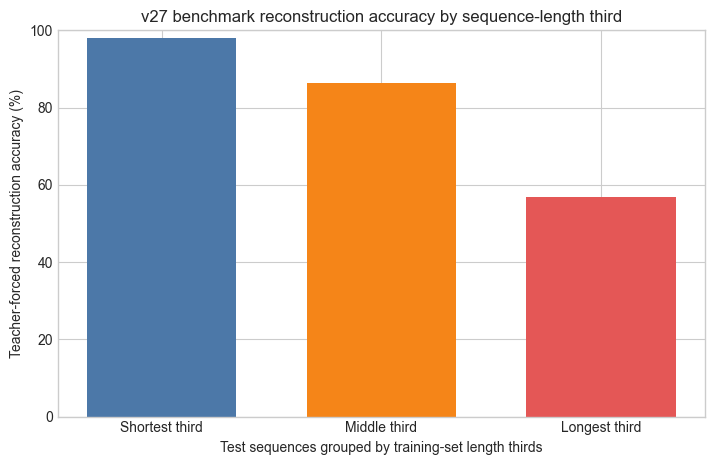

In [7]:
fig, ax = plt.subplots(figsize=(7.25, 4.75))
bars = ax.bar(
    v27_thirds["length_third"],
    100 * v27_thirds["reconstruction_accuracy"],
    color=["#4C78A8", "#F58518", "#E45756"],
    width=0.68,
)
ax.set_ylabel("Teacher-forced reconstruction accuracy (%)")
ax.set_title("v27 benchmark reconstruction accuracy by sequence-length third")
ax.set_ylim(0, 100)
ax.set_xlabel("Test sequences grouped by training-set length thirds")
fig.tight_layout()

v27_figure_path = FIGURES_DIR / "v27_teacher_forced_reconstruction_accuracy_by_length_third.pdf"
fig.savefig(v27_figure_path, format="pdf", bbox_inches="tight")
print(f"Saved {v27_figure_path}")
plt.show()